# **Proyecto de pruebas A/B**

El objetivo del proyecto fue evaluar si el nuevo sistema de recomendaciones incrementa en al menos 10% las tasas de conversión en cada etapa del embudo durante los primeros 14 días desde que se registro por primera vez el usuario. A través de un experimento A/B aplicado a nuevos usuarios de la UE, se midieron las tasas de conversión y su significancia estadística, con el fin de determinar si el cambio debía implementarse a nivel global.

In [1]:
import pandas as pd
import scipy.stats as stats 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Cargar archivos marketing 
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
print(marketing.info())
print(marketing.head())
print("\nDuplicados:\n", marketing.duplicated().sum())

# Convertir fechas
marketing['start_dt'] = pd.to_datetime(marketing['start_dt']) 
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes
None
                           name                   regions    start_dt  \
0      Christmas&New Year Promo             EU, N.America  2020-12-25   
1  St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2        St. Patric's Day Promo             EU, N.America  2020-03-17   
3                  Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4             4th of July Promo                 N.America  2020-07-04   

    finish_dt  
0  2021-01-03  
1  2020-02-16  
2  2020-03-19  
3  2020-04-19  
4  2020-07-11  

Duplicados:
 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0

In [3]:
# Verificar si hay campñas activas durante el período del test
marketing[
    (marketing['start_dt'] <= '2021-01-01') &
    (marketing['finish_dt'] >= '2020-12-07')]

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


In [4]:
# Cargar archivos new_users
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
print(new_users.info())
print(new_users.head())

print("\nDuplicados:\n", new_users.duplicated().sum())

# Convertir fechas
new_users['first_date'] = pd.to_datetime(new_users['first_date'])

# # Filtrar solo EU y fecha
print("\nFecha mínima:", new_users['first_date'].min())
print("Fecha máxima:", new_users['first_date'].max())

new_users = new_users[
    (new_users['region'] == 'EU') &
    (new_users['first_date'] >= '2020-12-07') &
    (new_users['first_date'] <= '2020-12-21')]

print(new_users.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB
None
            user_id  first_date     region   device
0  D72A72121175D8BE  2020-12-07         EU       PC
1  F1C668619DFE6E65  2020-12-07  N.America  Android
2  2E1BF1D4C37EA01F  2020-12-07         EU       PC
3  50734A22C0C63768  2020-12-07         EU   iPhone
4  E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone

Duplicados:
 0

Fecha mínima: 2020-12-07 00:00:00
Fecha máxima: 2020-12-23 00:00:00
(39466, 4)


In [5]:
# Cargar archivos new_users
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
print(events.info())
print(events.head())

events['event_dt'] = pd.to_datetime(events['event_dt'])

# Revisar valores nulos o duplicados 
print("\nValores nulos:\n", events.isnull().sum())
print("\nDuplicados:\n", events.duplicated().sum())

events_dup = events.groupby('event_name')['details'].apply(lambda x: x.notnull().sum())
print(events_dup)

print(events.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB
None
            user_id             event_dt event_name  details
0  E1BDDCE0DAFA2679  2020-12-07 20:22:03   purchase    99.99
1  7B6452F081F49504  2020-12-07 09:22:53   purchase     9.99
2  9CD9F34546DF254C  2020-12-07 12:59:29   purchase     4.99
3  96F27A054B191457  2020-12-07 04:02:40   purchase     4.99
4  1FD7660FDF94CA1F  2020-12-07 10:15:09   purchase     4.99

Valores nulos:
 user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Duplicados:
 0
event_name
login               0
product_cart        0
product_page        0
purchas

La columna details tiene sentido para purchase (valores estructuralmente vacíos) porque es el monto del pedido, los otros eventos no tienen monto asociado.

In [6]:
events['event_name'].value_counts()

login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64

In [7]:
print(events['event_dt'].min())
print(events['event_dt'].max())

2020-12-07 00:00:33
2020-12-30 23:36:33


La finaliza el 1 de enero, pero los eventos llegan hasta el 30 de diciembre. En realidad ninguno de los usuarios registrados después del día 16 tienen 14 días completos observables. 

In [8]:
# Cargar archivos participants
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')
print(participants.info())
print(participants.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB
None
            user_id group                  ab_test
0  D1ABA3E2887B6A73     A  recommender_system_test
1  A7A3664BD6242119     A  recommender_system_test
2  DABC14FDDFADD29E     A  recommender_system_test
3  04988C5DF189632E     A  recommender_system_test
4  4FF2998A348C484F     A  recommender_system_test


**¿Es necesario convertir los tipos?**

Sí, fue necesario convertir algunas columnas a tipo datetime para poder filtrar la ventana de 14 días y analizar la distribucón temporal.

**¿Hay valores ausentes o duplicados? Si es así, ¿cómo los caracterizarías?**

Se identificaron valores ausentes en la columna details, principalmente asociados a eventos de tipo purchase. Sin embargo, este campo no fue utilizado para el cálculo de las tasas de conversión, ya que el análisis se basó únicamente en la presencia del evento purchase por usuario dentro.

In [9]:
# Filtrar participantes correctamente
participants = participants[
    participants['ab_test'] == 'recommender_system_test'
]

print(participants.shape)
print(participants['group'].value_counts())

(3675, 3)
A    2747
B     928
Name: group, dtype: int64


In [10]:
# Unir participants con new_users
participants = participants.merge(
    new_users[['user_id', 'first_date']],
    on='user_id',
    how='inner'
)

print(participants.shape)
print(participants['group'].value_counts())
participants.groupby('user_id')['group'].nunique().value_counts()

(3481, 4)
A    2604
B     877
Name: group, dtype: int64


1    3481
Name: group, dtype: int64

Ningun usuario está en ambos grupos 

In [11]:
print(participants.columns)

# Unir eventos con participantes
ab_data = events.merge(
    participants[['user_id', 'group', 'first_date']],
    on='user_id',
    how='inner'
)

print(ab_data.shape)

Index(['user_id', 'group', 'ab_test', 'first_date'], dtype='object')
(22674, 6)


In [12]:
print(ab_data.columns)

# Aplicar ventana de 14 días
ab_data = ab_data[
    (ab_data['event_dt'] >= ab_data['first_date']) &
    (ab_data['event_dt'] <= ab_data['first_date'] + pd.Timedelta(days=14))
]

print(ab_data.shape)

Index(['user_id', 'event_dt', 'event_name', 'details', 'group', 'first_date'], dtype='object')
(21952, 6)


Estadísticas Grupo A
count    2604.000000
mean        6.619432
std         3.667608
min         1.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        24.000000
Name: event_count, dtype: float64

Estadísticas Grupo B
count    877.000000
mean       5.376283
std        3.228340
min        1.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       24.000000
Name: event_count, dtype: float64


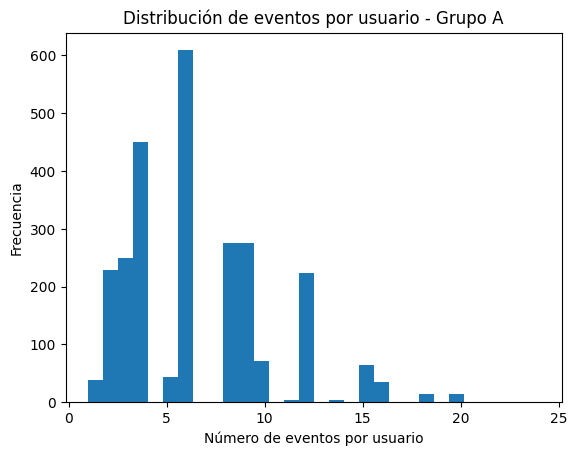

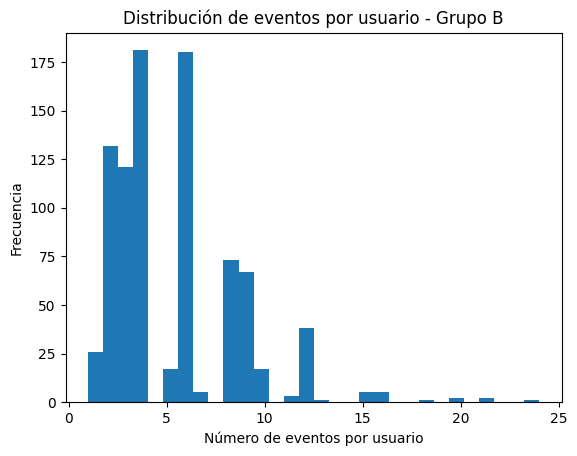

In [20]:
# Contar número de eventos por usuario y grupo
events_per_user = (ab_data.groupby(['user_id', 'group'])
    .size().reset_index(name='event_count'))

# Separar por grupo
group_A = events_per_user[events_per_user['group'] == 'A']['event_count']
group_B = events_per_user[events_per_user['group'] == 'B']['event_count']

# Estadísticas descriptivas
print("Estadísticas Grupo A")
print(group_A.describe())

print("\nEstadísticas Grupo B")
print(group_B.describe())


# Gráfica 1: Distribución Grupo A
plt.figure()
plt.hist(group_A, bins=30)
plt.xlabel("Número de eventos por usuario")
plt.ylabel("Frecuencia")
plt.title("Distribución de eventos por usuario - Grupo A")
plt.show()


# Gráfica 2: Distribución Grupo B
plt.figure()
plt.hist(group_B, bins=30)
plt.xlabel("Número de eventos por usuario")
plt.ylabel("Frecuencia")
plt.title("Distribución de eventos por usuario - Grupo B")
plt.show()

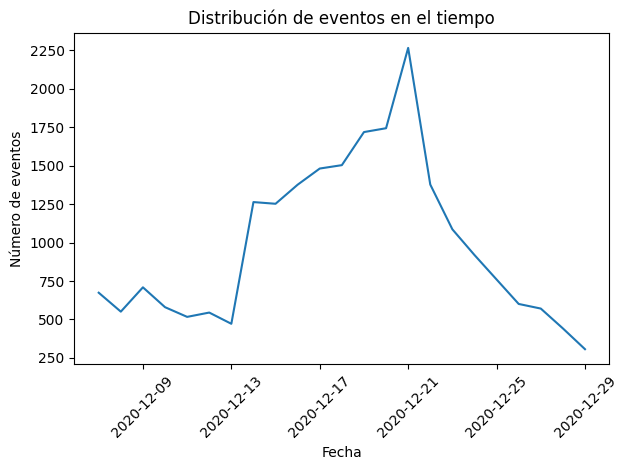

In [13]:
# Crear columna solo fecha
ab_data['event_date'] = ab_data['event_dt'].dt.date

# Contar eventos por día
events_per_day = ab_data.groupby('event_date').size()

plt.figure()
events_per_day.plot()
plt.xlabel("Fecha")
plt.ylabel("Número de eventos")
plt.title("Distribución de eventos en el tiempo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La distribución temporal de eventos muestra un incremento significativo en la actividad durante la segunda mitad de diciembre, con un pico alrededor del 20–21 de diciembre, seguido de una disminución progresiva hacia el final del mes. No se observan anomalías críticas ni días sin actividad que comprometan la validez del experimento.

**¿El número de eventos por usuario está distribuido equitativamente entre las muestras?**

Sí, no se observaron diferencias extremas en actividad promedio por usuario. Aunque el tamaño de muestra es desigual (A > B).

**¿Hay usuarios que están presentes en ambas muestras?**

No, cada user_id aparece en un solo grupo.

**¿Cómo se distribuye el número de eventos entre los días?**

La distribución temporal de eventos muestra un incremento significativo en la actividad durante la segunda mitad de diciembre, con un pico alrededor del 20–21 de diciembre, seguido de una disminución progresiva hacia el final del mes.

**¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?**

Una peculiaridad importante es que los grupos no están bien balanceados en tamaño.

Grupo A → 2604

Grupo B → 877

In [14]:
# Construir embudo por usuario 
funnel = ab_data.pivot_table(
    index=['user_id', 'group'],
    columns='event_name',
    values='event_dt',
    aggfunc='min'
).reset_index()

# Convertimos en indicadores 0/1
for col in ['product_page', 'product_cart', 'purchase']:
    funnel[col] = funnel[col].notna().astype(int)

funnel.head()

event_name,user_id,group,login,product_cart,product_page,purchase
0,001064FEAAB631A1,B,2020-12-20 14:43:27,0,1,0
1,0010A1C096941592,A,2020-12-17 21:07:27,0,1,1
2,00341D8401F0F665,A,2020-12-21 11:14:50,0,0,0
3,003DF44D7589BBD4,A,2020-12-17 06:17:49,1,1,0
4,00505E15A9D81546,A,2020-12-14 17:28:32,0,0,0


In [15]:
conversion = funnel.groupby('group')[['product_page', 'product_cart', 'purchase']].mean()

print(conversion)

event_name  product_page  product_cart  purchase
group                                           
A               0.647081      0.300307  0.319892
B               0.562144      0.278221  0.283922


In [16]:
lift = (conversion.loc['B'] - conversion.loc['A']) / conversion.loc['A']
print(lift)

event_name
product_page   -0.131263
product_cart   -0.073545
purchase       -0.112444
dtype: float64


B tiene 13% menos usuarios que llegan a product_page
7% menos que agregan al carrito
11% menos que compran

El objetivo era +10% de aumento, pero obtuvimos -11% en compras.

In [17]:
# Z-test

results = {}

for event in ['product_page', 'product_cart', 'purchase']:
    
    count = [
        funnel[funnel['group']=='A'][event].sum(),
        funnel[funnel['group']=='B'][event].sum()
    ]
    
    nobs = [
        funnel[funnel['group']=='A'][event].count(),
        funnel[funnel['group']=='B'][event].count()
    ]
    
    stat, pval = proportions_ztest(count, nobs)
    
    results[event] = pval

alpha = 0.05 / 3 
print("Aplpha:", alpha)
print()
print(results)

Aplpha: 0.016666666666666666

{'product_page': 6.94273935952599e-06, 'product_cart': 0.21469192029582396, 'purchase': 0.04652482738393029}


### Evaluacón de la prueba A/B

Lift relativo del grupo B:

product_page: -13.1%
product_cart: -7.3%
purchase: -11.2%

El nuevo sistema no solo no mejora el rendimiento, sino que lo reduce.

**Prueba Z**

Se realizó la correccón por 3 pruebas para evitar falsos positivos y se obtuvo que el valor-p de product_page tiene una diferencia significativa con alpha, llegando a la conclusión que el nuevo sistema reduce significativamente la llegada a product_page.
No hay evidencia suficiente para afirmar diferencias en product_cart o purchase. Sin embargo, la tendencia general es negativa en todas las etapas.

Dado que el experimento no alcanza la mejora esperada del 10% y muestra incluso una disminución en conversiones, se recomienda no implementar el nuevo sistema de recomendación.